# Solution: Count Unique Tokens (Monthly Algorithmic Challenge, May 2026)

## 0. The task

The input is a list of ten symbols drawn from the alphabet $\{\mathtt{a}, \mathtt{b}, \dots, \mathtt{j}\}$, with repeats allowed. The output is the number of distinct symbols in the list.

Example. For the input $\mathtt{a\,b\,a\,c\,a\,b\,d\,a\,c\,e}$ the distinct symbols are $\{\mathtt{a}, \mathtt{b}, \mathtt{c}, \mathtt{d}, \mathtt{e}\}$, so the answer is $5$.

A useful way to write the answer. For each symbol $k$ define a bit that is $1$ if $k$ appears anywhere in the list and $0$ otherwise. The answer is the sum of the ten bits. The model computes exactly this sum, so the whole solution is about where each bit is computed and how the bits get added.

## 1. The model, written out

### 1.1 Tokens

The vocabulary has 22 tokens:

- ids $0$ to $9$ are the symbols $\mathtt{a}$ to $\mathtt{j}$
- id $10$ is $\mathrm{BOS}$, a fixed start token
- id $11$ is $\mathrm{ANS}$, a fixed "answer now" token
- ids $12$ to $21$ are the ten possible answers, written $\#1$ to $\#10$

The model reads a sequence of 12 tokens,

$$x_0 = \mathrm{BOS}, \quad x_1 = t_1, \quad \dots, \quad x_{10} = t_{10}, \quad x_{11} = \mathrm{ANS},$$

where $t_1, \dots, t_{10}$ are the ten input symbols. Positions are numbered $0$ to $11$. The prediction is read at position $11$, the $\mathrm{ANS}$ position.

### 1.2 Embedding (the starting residual stream)

Every token id $k$ owns a vector $E_k \in \mathbb{R}^{32}$ (row $k$ of a $22 \times 32$ matrix). The model starts by placing the embedding of each token at its position:

$$r^{(0)}_j = E_{x_j}, \qquad j = 0, \dots, 11 .$$

The vector $r_j$ is called the residual stream at position $j$. Each layer will add something to it. There are **no positional embeddings**, so at this point the vector at position $j$ says which token is there and nothing about where $j$ is.

### 1.3 One attention head

A head has three $8 \times 32$ matrices $W_Q$, $W_K$, $W_V$ and one $32 \times 8$ matrix $W_O$. Given the residual vectors $r_0, \dots, r_{11}$ at its input, it computes, for every position $j$,

$$q_j = W_Q r_j \quad (\text{query}), \qquad k_j = W_K r_j \quad (\text{key}), \qquad v_j = W_V r_j \quad (\text{value}),$$

all in $\mathbb{R}^{8}$. Then for every pair of positions $i$ (the position that is "looking") and $j \le i$ (a position it may look at), the score is

$$s_{ij} = \dfrac{q_i \cdot k_j}{\sqrt{8}} .$$

Positions $j > i$ are masked out (causal mask), so position $i$ can only look at itself and earlier positions. The scores are turned into attention weights with a softmax over the allowed $j$:

$$A_{ij} = \dfrac{e^{s_{ij}}}{\sum_{j' \le i} e^{s_{ij'}}}, \qquad A_{ij} \ge 0, \qquad \sum_{j \le i} A_{ij} = 1 .$$

The head output at position $i$ is the weighted average of the values, projected back to 32 dimensions:

$$z_i = \sum_{j \le i} A_{ij}\, v_j \in \mathbb{R}^8, \qquad \Delta_i = W_O z_i \in \mathbb{R}^{32} .$$

Two facts about this that the solution uses repeatedly:

- The output is a **convex combination** of the vectors $W_O W_V r_j$ over the positions $j$ it attends to. A head cannot create new information; it can only mix what is at the attended positions. We write $W_{OV} = W_O W_V$ (a $32 \times 32$ matrix) for the map "what one attended vector contributes".
- If one score is larger than all the others by 5 or more, then since $e^{5} \approx 150$ the softmax puts almost all the weight on that one position. Large score gaps make attention effectively a hard $\arg\max$.

### 1.3b What "the head attends to $j$" means

"Attending to" is a name for where the weights $A_{ij}$ go. When the head computes its output at position $i$, the row $A_{i0}, A_{i1}, \dots, A_{ii}$ is a probability distribution over the positions it is allowed to look at. "The head attends to position $j$" means $A_{ij}$ is close to $1$. "The head attends to symbol $\mathtt{b}$" means the weight lands on positions that hold a $\mathtt{b}$.

What that does. The output at $i$ is the weighted average

$$\Delta_i = \sum_{j \le i} A_{ij}\, W_{OV}\, r_j ,$$

so if $A_{ij} \approx 1$ for a single $j$ then $\Delta_i \approx W_{OV} r_j$. Attending to $j$ means **copying the vector at position $j$, after the fixed linear map $W_{OV}$, into position $i$'s residual stream**. A head cannot write anything that is not already sitting at one of the positions it looks at. It only chooses which positions to copy from and how to mix them.

Where the weights come from. Position $i$ builds a query $q_i = W_Q r_i$ ("what I am looking for") and every position $j$ builds a key $k_j = W_K r_j$ ("what I have"). A key that points the same way as the query gets a high score $s_{ij}$ and therefore a high weight. So $W_Q$ and $W_K$ decide *where* to look, and $W_{OV}$ decides *what gets copied* from there. The two roles are independent, which is why later sections analyze the "QK circuit" and the "OV circuit" of a head separately.

Copies of a symbol share the weight. In layer 0 the residual at position $j$ is just $E_{x_j}$, so every position holding the same symbol has the same key and the same score. If there are three $\mathtt{a}$'s and the head is attending to $\mathtt{a}$, each gets weight about $1/3$, and the output is the same as if it had attended to one of them, since all three carry the same vector $E_{\mathtt{a}}$.

In the worked example $\mathtt{a\,b\,a\,c\,a\,b\,d\,a\,c\,e}$, head L1H0 at the $\mathrm{ANS}$ position has $A_{11,2} = 0.97$ (the first $\mathtt{b}$, at position 2) and $A_{11,6} = 0.03$ (the second $\mathtt{b}$). Its output at $\mathrm{ANS}$ is therefore $\Delta^{(1,0)}_{\mathrm{ANS}} \approx W^{(1,0)}_{OV}\, r^{(1)}_2$. For an input with no $\mathtt{b}$ the same head has $A_{11,0} \approx 1$ and its output is $W^{(1,0)}_{OV}\, r^{(1)}_{\mathrm{BOS}}$. Those two possible outputs differ by about one unit along the count direction $\mathbf{v}$, which is how "is there a $\mathtt{b}$" becomes "+1 to the count".

### 1.4 A layer, and the whole network

A layer has 4 heads. Their outputs are added to the residual stream. There is no MLP and no LayerNorm, so that is the entire layer:

$$r^{(1)}_i = r^{(0)}_i + \sum_{h=0}^{3} \Delta^{(0,h)}_i \qquad (\text{after layer } 0),$$

$$r^{(2)}_i = r^{(1)}_i + \sum_{h=0}^{3} \Delta^{(1,h)}_i \qquad (\text{after layer } 1).$$

Here $\Delta^{(L,h)}_i$ is the output of head $h$ of layer $L$ at position $i$. Layer 1's heads compute their queries, keys and values from $r^{(1)}$, so they can read whatever layer 0 wrote.

### 1.5 Readout

The unembedding is a $22 \times 32$ matrix; write $u_c$ for the row belonging to the answer token $\#c$. The logit of answer $c$ is

$$\ell_c = u_c \cdot r^{(2)}_{11}, \qquad c = 1, \dots, 10,$$

and the prediction is $\arg\max_c \ell_c$. Only position 11 (the $\mathrm{ANS}$ position) matters for the prediction, so from here on we mostly look at that position and write $r_{\mathrm{ANS}} = r^{(2)}_{11}$.

### 1.6 What "no positional embeddings" buys us

In layer 0 the residual at position $j$ is just $E_{x_j}$, so a layer-0 score is

$$s_{ij} = \dfrac{(W_Q E_{x_i}) \cdot (W_K E_{x_j})}{\sqrt{8}} = S(x_i, x_j),$$

a function of the two token identities only. Each layer-0 head is fully described by a $22 \times 22$ table $S(q, k)$ (query token, key token). A layer-0 head at position $i$ therefore attends over the bag of tokens at positions $0, \dots, i$, and its output depends only on which tokens are in that bag and how many copies of each, never on their order. Sections 6 and 7 read these tables directly.

### 1.7 Notation cheat sheet

- $t_1, \dots, t_{10}$: the ten input symbols.
- $M_j = \{t_1, \dots, t_j\}$: the set of distinct symbols that have appeared at positions $1$ to $j$ (the "prefix set"). $M_{10}$ is the set of all distinct symbols in the input.
- $U = |M_{10}|$: the correct answer.
- $[P]$: the Iverson bracket, equal to $1$ if the statement $P$ is true and $0$ otherwise. For example $[\mathtt{a} \in M_j]$ is $1$ if an $\mathtt{a}$ has occurred at or before position $j$.
- $E_k$: embedding vector of token $k$.
- $r^{(0)}_j, r^{(1)}_j, r^{(2)}_j$: residual stream at position $j$ after the embedding, after layer 0, after layer 1. $r^{(1)}_{\mathrm{BOS}}$ and $r^{(1)}_{\mathrm{ANS}}$ mean positions $0$ and $11$.
- $r_{\mathrm{ANS}} = r^{(2)}_{11}$: the final residual at the answer position.
- $\Delta^{(L,h)}_j$: output of head $h$ of layer $L$ at position $j$, already multiplied by $W_O$.
- $\delta_j = \sum_h \Delta^{(0,h)}_j$: everything layer 0 adds at position $j$, so $r^{(1)}_j = E_{x_j} + \delta_j$.
- $W^{(L,h)}_{OV} = W_O^{(L,h)} W_V^{(L,h)}$: the $32 \times 32$ OV map of head $h$ in layer $L$.
- $S^{(h)}(q, k)$: the layer-0 score table of head $h$ (section 6).
- $u_c$ and $\ell_c = u_c \cdot r_{\mathrm{ANS}}$: unembedding row and logit of answer $c$.
- $\mathbf{v}$ and $\mathbf{r}_0$: the count direction and offset, $r_{\mathrm{ANS}} \approx U\mathbf{v} + \mathbf{r}_0$ (section 4).
- $\sigma(x)$: the count slope of a residual-space vector $x$, a scalar that measures how far $x$ pushes the prediction toward larger counts (section 6). One unit of count is $\sigma(\mathbf{v}) \approx 32.6$.
- $n_h$: the number of "its" symbols that layer-1 head $h$ counts (section 5).

## 2. The algorithm, step by step

### Step A. The target is a sum of ten bits

$$U = \sum_{k \in \{\mathtt{a}, \dots, \mathtt{j}\}} [k \in M_{10}] .$$

The model produces the ten bits in layer 0 and adds them in layer 1.

### Step B. Layer 0 turns each head into a presence detector

Take head L0H0. Its score table has the form $S(q, k) \approx \mu(q)\,\nu(k)$, and for almost every query symbol $q$ the factor $\mu(q)$ is positive and about the same size. So no matter which symbol is asking, the head ranks key symbols in one fixed order, given by $\nu$:

$$\mathtt{a} \succ \mathtt{c} \succ \mathtt{e} \succ \mathtt{j} \succ \mathtt{i} \succ \cdots$$

The gaps between consecutive scores are 5 to 10, so (section 1.3) the softmax is effectively an $\arg\max$. At position $i$ the head puts nearly all its weight on copies of the **highest-ranked symbol that occurs in positions $1$ to $i$**. If there is an $\mathtt{a}$ in the prefix it attends to the $\mathtt{a}$'s. If there is no $\mathtt{a}$ but there is a $\mathtt{c}$, it attends to the $\mathtt{c}$'s, and so on. The output is then

$$\Delta^{(0,0)}_i \approx W^{(0,0)}_{OV}\, E_{\tau_0(M_i)}, \qquad \tau_0(M) = \text{the top-ranked element of } M,$$

which is one of a handful of fixed vectors. Whether $\tau_0(M_i) = \mathtt{a}$, which is the bit $[\mathtt{a} \in M_i]$, is readable from it. The four heads have four different rankings, with tops $\mathtt{a}$, $\mathtt{h}$, $\mathtt{d}$, $\mathtt{g}$. So at every ordinary symbol position $i$ the residual $r^{(1)}_i$ carries the four bits

$$[\mathtt{a} \in M_i], \quad [\mathtt{h} \in M_i], \quad [\mathtt{d} \in M_i], \quad [\mathtt{g} \in M_i] .$$

The ranking is not quite the same for every query. The $\mathrm{ANS}$ query row has its own ranking in each head, with tops $\mathtt{i}$, $\mathtt{j}$, $\mathtt{c}$, $\mathtt{e}$. Since the $\mathrm{ANS}$ position sees the whole input, $r^{(1)}_{\mathrm{ANS}}$ carries the four bits

$$[\mathtt{i} \in M_{10}], \quad [\mathtt{j} \in M_{10}], \quad [\mathtt{c} \in M_{10}], \quad [\mathtt{e} \in M_{10}] .$$

That is eight of the ten bits from four heads. The last two symbols get special treatment in the query rows. $\mu(\mathtt{b}) < 0$, so a $\mathtt{b}$ query ranks keys in reverse and attends mostly to $\mathtt{b}$ and $\mathrm{BOS}$. $\mu(\mathtt{f}) \approx 0$, so an $\mathtt{f}$ query attends diffusely. Either way, $r^{(1)}_j$ at a $\mathtt{b}$ position or an $\mathtt{f}$ position looks unlike the residual at any other position, so layer 1 can find $\mathtt{b}$'s and $\mathtt{f}$'s directly by attention.

### Step C. Layer 1 adds the bits along one direction

There is a single direction $\mathbf{v} \in \mathbb{R}^{32}$ such that each layer-1 head, at the $\mathrm{ANS}$ position, adds $n_h \mathbf{v}$ plus a constant vector, where $n_h$ counts the symbols assigned to that head:

| head | $n_h$ | how the head gets $n_h$ into its output |
|---|---|---|
| L1H0 | $[\mathtt{b} \in M_{10}]$ | attends to the first $\mathtt{b}$ if there is one, else to $\mathrm{BOS}$; the two possible values differ by $\mathbf{v}$ |
| L1H1 | $[\mathtt{f} \in M_{10}]$ | attends to an $\mathtt{f}$ if there is one, else to a $\mathtt{g}$, $\mathtt{d}$ or $\mathtt{h}$ position; same idea |
| L1H2 | $[\mathtt{a} \in M_{10}] + [\mathtt{d} \in M_{10}] + [\mathtt{g} \in M_{10}] + [\mathtt{h} \in M_{10}]$ | attends to a position $j$ whose prefix $M_j$ already contains every $\mathtt{a}$, $\mathtt{d}$, $\mathtt{g}$, $\mathtt{h}$ of the input; the four layer-0 bits stored at that position are read out through $W^{(1,2)}_{OV}$ |
| L1H3 | $[\mathtt{c} \in M_{10}] + [\mathtt{e} \in M_{10}] + [\mathtt{i} \in M_{10}] + [\mathtt{j} \in M_{10}]$ | soft attention between $\mathrm{BOS}$ and everything else; the four layer-0 bits at $\mathrm{ANS}$ sit in the query and each one lowers the $\mathrm{BOS}$ score by about 1, so the $\mathrm{BOS}$ weight drops one step per present symbol; the $\mathrm{BOS}$ value points far along $-\mathbf{v}$ |

The four subsets partition the alphabet, so

$$n_0 + n_1 + n_2 + n_3 = U, \qquad r_{\mathrm{ANS}} \approx U \mathbf{v} + \mathbf{r}_0 .$$

### Step D. The readout turns "$U$ steps along $\mathbf{v}$" into "$\arg\max$ at $U$"

Plugging the residual into the logits,

$$\ell_c = u_c \cdot r_{\mathrm{ANS}} \approx U\,(u_c \cdot \mathbf{v}) + u_c \cdot \mathbf{r}_0 .$$

The unembedding rows are arranged so that the first dot product grows linearly with $c$ and the second is a downward parabola in $c$:

$$u_c \cdot \mathbf{v} \approx 32.6\, c + \text{const}, \qquad u_c \cdot \mathbf{r}_0 \approx -16.2\, c^2 - 10.8\, c + \text{const}.$$

So

$$\ell_c \approx 32.6\, U c - 16.2\, c^2 - 10.8\, c + \text{const}.$$

As a function of $c$ this is a downward parabola whose peak is at

$$c^\ast = \dfrac{32.6\, U - 10.8}{2 \cdot 16.2} \approx U - 0.33 .$$

The nearest integer is $U$, for every $U$ from 1 to 10. In words, the answer token $\#c$ "wants" the count to be near $c$, and the quadratic penalty makes exactly one of them win.

### Worked example

Input $\mathtt{a\,b\,a\,c\,a\,b\,d\,a\,c\,e}$, $M_{10} = \{\mathtt{a},\mathtt{b},\mathtt{c},\mathtt{d},\mathtt{e}\}$, $U = 5$:

- $n_0 = [\mathtt{b} \in M_{10}] = 1$
- $n_1 = [\mathtt{f} \in M_{10}] = 0$
- $n_2 = [\mathtt{a} \in M_{10}] + [\mathtt{d} \in M_{10}] + [\mathtt{g} \in M_{10}] + [\mathtt{h} \in M_{10}] = 1 + 1 + 0 + 0 = 2$
- $n_3 = [\mathtt{c} \in M_{10}] + [\mathtt{e} \in M_{10}] + [\mathtt{i} \in M_{10}] + [\mathtt{j} \in M_{10}] = 1 + 1 + 0 + 0 = 2$
- $n_0 + n_1 + n_2 + n_3 = 5$

The code cell after the setup runs the model on this input and prints where each layer-1 head attends and the resulting logits. Section 5 reads $n_h$ off each head's output for this example.

The rest of this notebook shows the evidence, section by section.

## Setup

In [1]:
%pip install -q torch einops huggingface_hub matplotlib

In [2]:
import json, importlib
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

torch.set_grad_enabled(False)
torch.set_printoptions(precision=2, sci_mode=False, linewidth=200)
np.set_printoptions(precision=2, suppress=True, linewidth=200)

REPO_ID = "andyrdt/05_2026_puzzle_1"
model_py_path = hf_hub_download(REPO_ID, "model.py")
spec = importlib.util.spec_from_file_location("model", model_py_path)
model_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_module)
config = json.loads(Path(hf_hub_download(REPO_ID, "config.json")).read_text())
model = model_module.AttentionOnlyTransformer.from_config(config["model"])
model.load_state_dict(torch.load(hf_hub_download(REPO_ID, "model.pt"), map_location="cpu", weights_only=True))
model.eval()

NUM_SYMBOLS, SEQ_LEN = 10, 10
BOS, ANS, COUNT_BASE, VOCAB_SIZE, D_HEAD = 10, 11, 12, 22, 8
SYM = [chr(97 + k) for k in range(10)]
LABELS = SYM + ["BOS", "ANS"]
E = model.tok_embed.weight                       # (22, 32)
W_U = model.unembed.weight[COUNT_BASE:]          # (10, 32) rows for #1..#10
L0, L1 = model.layers

def encode(symbols):
    return [BOS] + [ord(s) - 97 if isinstance(s, str) else int(s) for s in symbols] + [ANS]

def random_sequence(rng, c):
    symbols = rng.choice(NUM_SYMBOLS, size=c, replace=False)
    extras = rng.choice(symbols, size=SEQ_LEN - c, replace=True)
    seq = np.concatenate([symbols, extras]); rng.shuffle(seq)
    return seq.tolist()

def random_batch(rng, n_per_count):
    seqs, counts = [], []
    for c in range(1, SEQ_LEN + 1):
        for _ in range(n_per_count):
            seqs.append([BOS] + random_sequence(rng, c) + [ANS]); counts.append(c)
    return torch.tensor(seqs), torch.tensor(counts)

def run(x):
    # Returns per-component contributions to the residual stream at every position, plus attention patterns.
    b, s = x.shape
    h = E[x]
    mask = torch.tril(torch.ones(s, s)).unsqueeze(0)
    comps, attns, resid = {"embed": h.clone()}, [], {}
    for L, layer in enumerate(model.layers):
        outs, a_l = [], []
        for hi, head in enumerate(layer.heads):
            o, a = head(h, mask)
            outs.append(o); a_l.append(a)
            comps[f"L{L}H{hi}"] = o @ layer.W_O.weight[:, hi * D_HEAD:(hi + 1) * D_HEAD].T
        h = h + layer.W_O(torch.cat(outs, -1))
        attns.append(torch.stack(a_l, 1)); resid[L] = h.clone()
    return comps, resid, attns

def presence_matrix(x):
    B = len(x); P = torch.zeros(B, 10)
    for b in range(B):
        P[b, x[b, 1:-1]] = 1
    return P

def prefix_presence(x):
    # pp[b, j, k] = 1 if symbol k occurs in t1..t_{j+1}
    B = len(x); pp = torch.zeros(B, SEQ_LEN, 10)
    for b in range(B):
        seen = torch.zeros(10)
        for j in range(SEQ_LEN):
            seen[x[b, j + 1]] = 1; pp[b, j] = seen
    return pp

IDX = torch.arange(1, 11).float()
IDX_C = IDX - IDX.mean()
def count_slope(resid_vec):
    # Project a residual-space vector to logits over #1..#10 and return the slope of that logit vector against c.
    lg = resid_vec @ W_U.T
    return (lg * IDX_C).sum(-1) / (IDX_C ** 2).sum()

rng = np.random.default_rng(0)
X, C = random_batch(rng, 300)
COMPS, RESID, ATTNS = run(X)
P = presence_matrix(X)
PP = prefix_presence(X)
SEQS = X[:, 1:-1]
pred = (RESID[1][:, -1] @ W_U.T).argmax(-1) + 1
print(f"accuracy on {len(C)} random sequences: {(pred == C).float().mean():.4f}")

accuracy on 3000 random sequences: 1.0000


### The worked example on the real model

Where each layer-1 head sends its attention from the $\mathrm{ANS}$ position, and the resulting logits, for the input $\mathtt{a\,b\,a\,c\,a\,b\,d\,a\,c\,e}$. Position numbers follow section 1.1 ($\mathrm{BOS}$ is position 0, $t_1$ is position 1, and so on).

In [3]:
EXAMPLE = list("abacabdace")
x_ex = torch.tensor([encode(EXAMPLE)])
comps_ex, resid_ex, attns_ex = run(x_ex)
labels_ex = ["BOS"] + EXAMPLE + ["ANS"]
print("input:", " ".join(EXAMPLE), "   distinct symbols:", sorted(set(EXAMPLE)), "   U =", len(set(EXAMPLE)))
for hd in range(4):
    a = attns_ex[1][0, hd, -1]
    top = torch.argsort(a, descending=True)[:3]
    parts = [f"{labels_ex[j]} at position {j} (weight {a[j]:.2f})" for j in top.tolist() if a[j] > 0.02]
    print(f"  L1H{hd} attends to: " + ";  ".join(parts))
lg = resid_ex[1][0, -1] @ W_U.T
print("logits for #1..#10:", lg.numpy().round(0))
print("prediction:", int(lg.argmax()) + 1)

input: a b a c a b d a c e    distinct symbols: ['a', 'b', 'c', 'd', 'e']    U = 5
  L1H0 attends to: b at position 2 (weight 0.97);  b at position 6 (weight 0.03)
  L1H1 attends to: d at position 7 (weight 1.00)
  L1H2 attends to: e at position 10 (weight 0.83);  c at position 9 (weight 0.15)
  L1H3 attends to: BOS at position 0 (weight 0.50);  a at position 1 (weight 0.08);  a at position 3 (weight 0.08)
logits for #1..#10: [-142.  -39.   49.  103.  124.  110.   61.  -20. -127. -266.]
prediction: 5


## 3. Everything that matters happens in the four layer-1 heads at $\mathrm{ANS}$

With no MLPs and no LayerNorm the final residual is an exact sum,

$$r_{\mathrm{ANS}} = E_{\mathrm{ANS}} + \sum_{h=0}^{3} \Delta^{(0,h)}_{\mathrm{ANS}} + \sum_{h=0}^{3} \Delta^{(1,h)}_{\mathrm{ANS}} .$$

Zero-ablating any $\Delta^{(0,h)}_{\mathrm{ANS}}$ leaves accuracy at 100%. Zeroing any $\Delta^{(1,h)}_{\mathrm{ANS}}$ breaks the model. Keeping only the four layer-1 terms keeps 100%.

Layer 0 still matters, through the keys, values and queries it prepares for layer 1 (section 6).

In [4]:
final = RESID[1][:, -1]
def acc_of(vec):
    return ((vec @ W_U.T).argmax(-1) + 1 == C).float().mean().item()

print("zero-ablate one component of the ANS residual:")
for name, v in COMPS.items():
    print(f"  without {name:6s}: acc = {acc_of(final - v[:, -1]):.3f}")
print("keep only L1H0..L1H3:", f"acc = {acc_of(sum(COMPS[f'L1H{h}'][:, -1] for h in range(4))):.3f}")
print("keep only embed + L0H0..L0H3:", f"acc = {acc_of(COMPS['embed'][:, -1] + sum(COMPS[f'L0H{h}'][:, -1] for h in range(4))):.3f}")

zero-ablate one component of the ANS residual:
  without embed : acc = 1.000
  without L0H0  : acc = 1.000
  without L0H1  : acc = 1.000
  without L0H2  : acc = 1.000
  without L0H3  : acc = 1.000
  without L1H0  : acc = 0.209
  without L1H1  : acc = 0.557
  without L1H2  : acc = 0.206
  without L1H3  : acc = 0.132
keep only L1H0..L1H3: acc = 1.000
keep only embed + L0H0..L0H3: acc = 0.143


## 4. The readout: the residual at $\mathrm{ANS}$ moves along one direction, $U$ steps for $U$ unique symbols

A least-squares fit of $r_{\mathrm{ANS}} \approx U \mathbf{v} + \mathbf{r}_0$ over random sequences gives $R^2 \approx 0.97$. Projecting the unembedding rows onto $\mathbf{v}$ gives a line in $c$, and onto $\mathbf{r}_0$ a concave parabola:

$$u_c \cdot \mathbf{v} \approx 32.6\, c - 216, \qquad u_c \cdot \mathbf{r}_0 \approx -16.2\, c^2 - 10.8\, c + 845 .$$

Together,

$$\ell_c = u_c \cdot r_{\mathrm{ANS}} \approx 32.6\, U c - 16.2\, c^2 - 10.8\, c + \text{const},$$

which is maximized at $c^\ast = \dfrac{32.6\, U - 10.8}{2 \cdot 16.2} \approx U - 0.33$, so the nearest integer is $U$ for every $U \in \{1, \dots, 10\}$.

resid_ANS ~ U*v + r0:  R^2 = 0.972
u_c . v  = [-179.5 -154.1 -120.7  -86.9  -52.1  -16.3   19.4   53.3   85.1  117. ]   ~ 32.4 c + -216.5  (c^2 coeff 0.12)
u_c . r0 = [ 796.7  761.8  674.7  552.1  392.2  193.1  -39.1 -293.7 -563.4 -866. ]   ~ -16.2 c^2 + -9.9 c + 839.3
=> logit_c ~ 32.4 U c -16.2 c^2 -9.9 c + const
argmax_c of that quadratic for U = 1..10: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


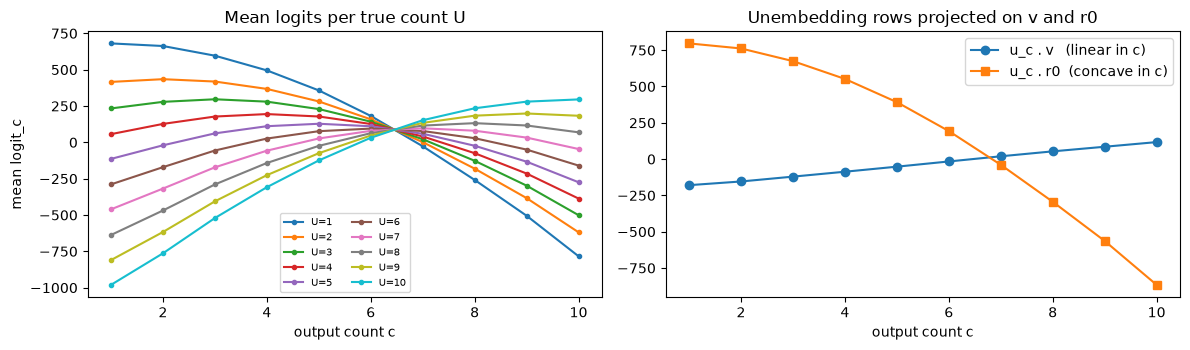

In [5]:
X1 = torch.stack([C.float(), torch.ones(len(C))], 1)
W = torch.linalg.lstsq(X1, final).solution
g, r0 = W[0], W[1]
res = final - X1 @ W
print(f"resid_ANS ~ U*v + r0:  R^2 = {1 - (res**2).sum() / ((final - final.mean(0))**2).sum():.3f}")
A = torch.stack([IDX**2, IDX, torch.ones(10)], 1)
cg = torch.linalg.lstsq(A, (W_U @ g).unsqueeze(1)).solution.squeeze()
cr = torch.linalg.lstsq(A, (W_U @ r0).unsqueeze(1)).solution.squeeze()
print("u_c . v  =", (W_U @ g).numpy().round(1), f"  ~ {cg[1]:.1f} c + {cg[2]:.1f}  (c^2 coeff {cg[0]:.2f})")
print("u_c . r0 =", (W_U @ r0).numpy().round(1), f"  ~ {cr[0]:.1f} c^2 + {cr[1]:.1f} c + {cr[2]:.1f}")
print(f"=> logit_c ~ {cg[1]:.1f} U c {cr[0]:+.1f} c^2 {cr[1]:+.1f} c + const")
print("argmax_c of that quadratic for U = 1..10:", [int(torch.argmax(cg[1]*u*IDX + cr[0]*IDX**2 + cr[1]*IDX)) + 1 for u in range(1, 11)])

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
lg = final @ W_U.T
for u in range(1, 11):
    ax[0].plot(range(1, 11), lg[C == u].mean(0), marker="o", ms=3, label=f"U={u}")
ax[0].set_xlabel("output count c"); ax[0].set_ylabel("mean logit_c"); ax[0].set_title("Mean logits per true count U"); ax[0].legend(fontsize=7, ncol=2)
ax[1].plot(range(1, 11), W_U @ g, marker="o", label="u_c . v   (linear in c)")
ax[1].plot(range(1, 11), W_U @ r0, marker="s", label="u_c . r0  (concave in c)")
ax[1].set_xlabel("output count c"); ax[1].legend(); ax[1].set_title("Unembedding rows projected on v and r0")
plt.tight_layout(); plt.show()

## 5. Each layer-1 head counts a fixed subset of the alphabet

Each layer-1 head's logit contribution $u_c \cdot \Delta^{(1,h)}_{\mathrm{ANS}}$ is a linear function of the ten presence bits ($R^2$ = 1.00, 0.97, 0.89, 0.99):

$$u_c \cdot \Delta^{(1,h)}_{\mathrm{ANS}} \approx \sum_{k} [k \in M_{10}]\, \beta^{(h)}_{k}(c) + \beta^{(h)}_0(c).$$

Summarizing each fitted logit vector $\beta^{(h)}_k(c)$ by its slope in $c$ (the amount that symbol $k$ pushes head $h$ toward larger counts) shows the partition. Every symbol ends up with a slope near 34 in the sum over heads, so the total slope is $\approx 34\, U$.

The last lines of the cell return to the worked example. For each head they take the count slope of the head's actual output, subtract the slope of the fitted intercept $\beta^{(h)}_0$, and divide by one unit of count, $\sigma(\mathbf{v})$. The result is close to the $n_h$ listed in section 2.

head        a      b      c      d      e      f      g      h      i      j     R^2
L1H0      0.0   37.5   -0.1    0.0    0.0    0.0    0.0    0.0   -0.0    0.0   1.000
L1H1     -1.4    1.3   -0.0    0.4   -0.1   35.1    0.0   -0.2   -0.8   -0.5   0.973
L1H2     33.4   -7.9    4.5   33.3    5.2    0.1   32.7   33.5    5.0    8.1   0.885
L1H3      1.9   -3.2   30.4    0.4   28.7   -1.1    1.7    0.8   30.0   27.3   0.988
sum      33.9   27.7   34.8   34.1   33.8   34.0   34.5   34.2   34.1   34.9


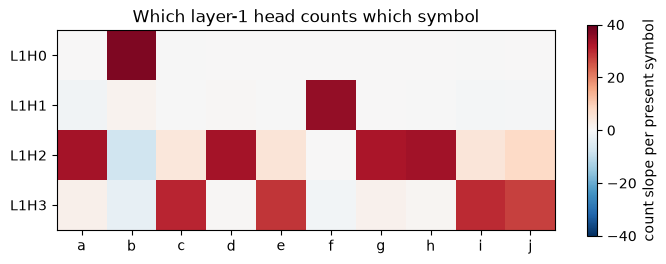


worked example 'abacabdace':  n_h read from each head as (slope of head output - intercept slope) / 32.4
  L1H0: (   52.2 - (   14.7)) / 32.4 =  1.16    n_h = 1
  L1H1: (  -23.9 - (  -23.3)) / 32.4 = -0.02    n_h = 0
  L1H2: (   32.8 - (  -42.8)) / 32.4 =  2.33    n_h = 2
  L1H3: (  -74.0 - ( -135.3)) / 32.4 =  1.89    n_h = 2


In [6]:
def fit_presence(Y):
    Xp = torch.cat([P, torch.ones(len(P), 1)], 1)
    Wp = torch.linalg.lstsq(Xp, Y).solution
    r2 = 1 - ((Xp @ Wp - Y) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()
    return Wp[:-1], Wp[-1], r2.item()

def slope_of(vec10):
    return ((IDX_C * (vec10 - vec10.mean())).sum() / (IDX_C**2).sum()).item()

rows, intercept_slopes = [], {}
print(f"{'head':6s} " + " ".join(f"{s:>6s}" for s in SYM) + "     R^2")
for name in ["L1H0", "L1H1", "L1H2", "L1H3"]:
    Wp, bias, r2 = fit_presence(COMPS[name][:, -1] @ W_U.T)
    slopes = [slope_of(Wp[k]) for k in range(10)]
    rows.append(slopes); intercept_slopes[name] = slope_of(bias)
    print(f"{name:6s} " + " ".join(f"{s:6.1f}" for s in slopes) + f"   {r2:.3f}")
tot = np.array(rows).sum(0)
print(f"{'sum':6s} " + " ".join(f"{s:6.1f}" for s in tot))

plt.figure(figsize=(7, 2.6))
plt.imshow(np.array(rows), cmap="RdBu_r", vmin=-40, vmax=40)
plt.xticks(range(10), SYM); plt.yticks(range(4), [f"L1H{h}" for h in range(4)])
plt.colorbar(label="count slope per present symbol"); plt.title("Which layer-1 head counts which symbol")
plt.tight_layout(); plt.show()

subsets = {"L1H0": [1], "L1H1": [5], "L1H2": [0, 3, 6, 7], "L1H3": [2, 4, 8, 9]}
P_ex = presence_matrix(x_ex)[0]
unit = cg[1].item()
print(f"\nworked example '{''.join(EXAMPLE)}':  n_h read from each head as (slope of head output - intercept slope) / {unit:.1f}")
for name, subset in subsets.items():
    actual = count_slope(comps_ex[name][0, -1]).item()
    n_h = int(P_ex[subset].sum())
    print(f"  {name}: ({actual:7.1f} - ({intercept_slopes[name]:7.1f})) / {unit:.1f} = {(actual - intercept_slopes[name]) / unit:5.2f}    n_h = {n_h}")

## 6. Layer 0: four presence detectors, each with a fixed key priority

There are no positional embeddings, so a layer-0 attention score depends only on the (query token, key token) pair,

$$S^{(h)}(q, k) = \dfrac{(W_Q^{(0,h)} E_q) \cdot (W_K^{(0,h)} E_k)}{\sqrt{8}} .$$

The $12 \times 12$ score matrices below are close to rank 1, $S^{(h)}(q, k) \approx \mu_h(q)\, \nu_h(k)$. For most query symbols $\mu_h(q) > 0$ with similar magnitude, so every ordinary query position attends with the **same** key ordering, given by $\nu_h$. Two exceptions: $\mu_h(\mathtt{b}) < 0$ (a $\mathtt{b}$ query reverses the ordering and attends mostly to $\mathtt{b}$ and $\mathrm{BOS}$), and $\mu_h(\mathtt{f}) \approx 0$ (an $\mathtt{f}$ query attends diffusely). The $\mathrm{ANS}$ query row has a different ordering again. It, together with the $\mathtt{f}$ row, carries most of the departure from rank 1 (the second singular value).

Because the score gaps are large (5 to 10 nats between successive priorities), each head is effectively a **hard priority encoder over its causal prefix**. Writing $\succ_h$ for the key ordering at symbol queries and $\succ_h^{\mathrm{ANS}}$ for the ordering at the $\mathrm{ANS}$ query, and $\tau_h(M) = \max_{\succ_h} M$ for the top-ranked element of a set $M$, the head output is approximately

$$\Delta^{(0,h)}_j \approx W^{(0,h)}_{OV}\, E_{\tau_h(M_j)} \quad (\text{ordinary symbol position } j), \qquad \Delta^{(0,h)}_{\mathrm{ANS}} \approx W^{(0,h)}_{OV}\, E_{\tau_h^{\mathrm{ANS}}(M_{10})} .$$

Whether or not the top symbol is present is therefore a presence bit readable from the head's output.

| head | $\succ_h$ (ordinary symbol queries) | $\succ_h^{\mathrm{ANS}}$ ($\mathrm{ANS}$ query) |
|---|---|---|
| L0H0 | $\mathbf{a} \succ \mathtt{c} \succ \mathtt{e} \succ \mathtt{j} \succ \mathtt{i} \succ \cdots$ | $\mathbf{i} \succ \mathtt{e} \succ \mathtt{j} \succ \mathtt{c} \succ \mathtt{g} \succ \cdots$ |
| L0H1 | $\mathbf{h} \succ \mathtt{j} \succ \mathtt{d} \succ \mathtt{g} \succ \mathtt{i} \succ \cdots$ | $\mathbf{j} \succ \mathtt{h} \succ \mathtt{d} \succ \mathtt{g} \succ \mathtt{i} \succ \cdots$ |
| L0H2 | $\mathbf{d} \succ$ everything else | $\mathbf{c} \succ \mathtt{i} \succ \mathtt{j} \succ \mathtt{e} \succ \cdots$ |
| L0H3 | $\mathbf{g} \succ \mathtt{i} \succ \mathtt{e} \succ \mathtt{j} \succ \cdots$ | $\mathbf{e} \succ \mathtt{i} \succ \mathtt{c} \succ \mathtt{d} \succ \cdots$ |

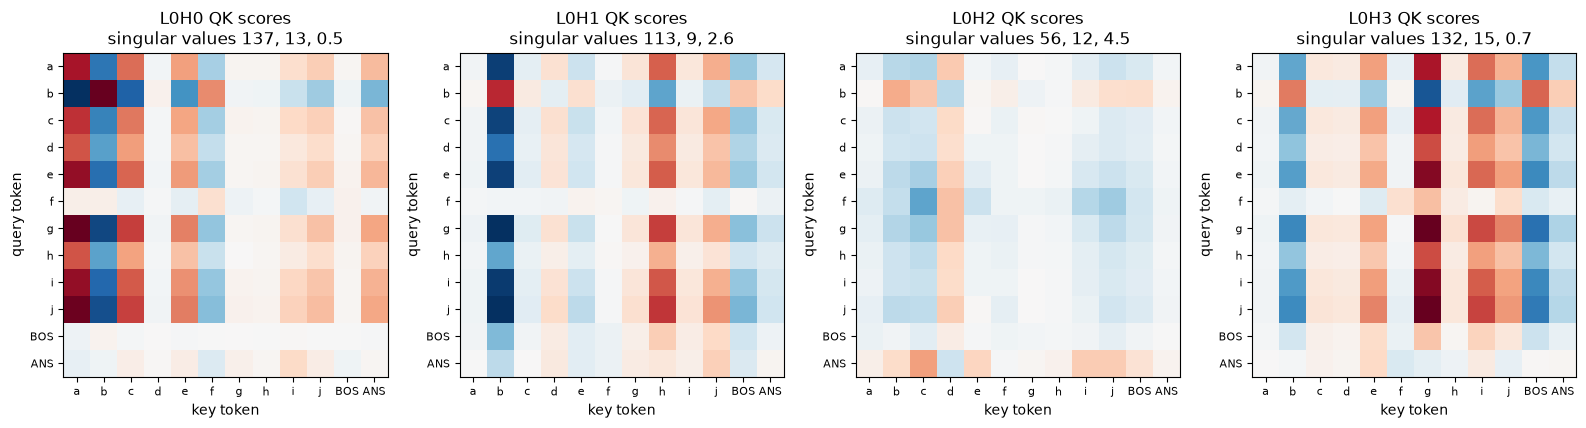

Key priority (descending score) for an ordinary query (row 'e') and for the ANS query:
  L0H0: symbol query: a > c > e > ANS > j > i    |    ANS query: i > e > j > c > g > ANS
  L0H1: symbol query: h > j > d > g > i > f    |    ANS query: j > h > d > g > i > ANS
  L0H2: symbol query: d > g > h > ANS > f > a    |    ANS query: c > i > j > e > b > BOS
  L0H3: symbol query: g > i > j > e > h > c    |    ANS query: e > i > c > d > ANS > BOS


In [7]:
def qk_matrix(layer, head):
    h = model.layers[layer].heads[head]
    return (h.W_Q(E) @ h.W_K(E).T)[:12, :12] / D_HEAD ** 0.5

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for hd in range(4):
    S = qk_matrix(0, hd)
    sv = torch.linalg.svdvals(S)
    ax = axes[hd]
    im = ax.imshow(S, cmap="RdBu_r", vmin=-30, vmax=30)
    ax.set_xticks(range(12)); ax.set_xticklabels(LABELS, fontsize=8); ax.set_yticks(range(12)); ax.set_yticklabels(LABELS, fontsize=8)
    ax.set_xlabel("key token"); ax.set_ylabel("query token")
    ax.set_title(f"L0H{hd} QK scores\nsingular values {sv[0]:.0f}, {sv[1]:.0f}, {sv[2]:.1f}")
plt.tight_layout(); plt.show()

print("Key priority (descending score) for an ordinary query (row 'e') and for the ANS query:")
for hd in range(4):
    S = qk_matrix(0, hd)
    order_sym = [LABELS[k] for k in torch.argsort(S[4], descending=True)[:6]]
    order_ans = [LABELS[k] for k in torch.argsort(S[ANS], descending=True)[:6]]
    print(f"  L0H{hd}: symbol query: {' > '.join(order_sym)}    |    ANS query: {' > '.join(order_ans)}")

Empirically the heads behave as hard detectors. At ordinary symbol positions, when the head's top symbol is in the prefix $M_j$, the head puts essentially all attention on copies of it. At $\mathrm{ANS}$, the same holds for the top symbol of $\succ_h^{\mathrm{ANS}}$.

In [8]:
A0 = ATTNS[0]                       # (B, 4, 12, 12)
full_pres = PP[:, -1]
print("Layer-0 attention from ordinary symbol positions (query not b/f): total weight on the top-priority symbol when it is in the prefix")
for hd, top in enumerate([0, 7, 3, 6]):
    qmask = (SEQS != 1) & (SEQS != 5) & (PP[:, :, top] == 1)
    att = A0[:, hd, 1:-1, 1:-1]
    on_top = (att * (SEQS.unsqueeze(1) == top)).sum(-1)
    print(f"  L0H{hd} -> '{SYM[top]}': {on_top[qmask].mean():.3f}")
print("Layer-0 attention from ANS: total weight on the top-priority symbol when it is present")
for hd, top in enumerate([8, 9, 2, 4]):
    pres = full_pres[:, top] == 1
    on_top = (A0[pres, hd, -1, 1:-1] * (SEQS[pres] == top)).sum(-1)
    print(f"  L0H{hd} -> '{SYM[top]}': {on_top.mean():.3f}")

Layer-0 attention from ordinary symbol positions (query not b/f): total weight on the top-priority symbol when it is in the prefix
  L0H0 -> 'a': 1.000
  L0H1 -> 'h': 0.999
  L0H2 -> 'd': 0.997
  L0H3 -> 'g': 1.000
Layer-0 attention from ANS: total weight on the top-priority symbol when it is present
  L0H0 -> 'i': 0.916
  L0H1 -> 'j': 0.959
  L0H2 -> 'c': 0.984
  L0H3 -> 'e': 0.949


The OV circuits turn "which symbol won" into a count-direction signal. Define the **count slope** of a residual-space vector $x$ as the slope of its logit vector against $c$,

$$\sigma(x) = \dfrac{\sum_{c=1}^{10} (c - \bar c)\, (u_c \cdot x)}{\sum_{c=1}^{10} (c - \bar c)^2}, \qquad \bar c = 5.5,$$

so that $\sigma(\mathbf{v}) \approx 32.6$ is one unit of count. Reading each layer-0 head's output for symbol $k$ through L1H2's value path, $\sigma\!\left(W^{(1,2)}_{OV} W^{(0,h)}_{OV} E_k\right)$, the head's top symbol stands out from every alternative it could attend to ($\mathtt{a}$ via L0H0, $\mathtt{h}$ via L0H1, $\mathtt{d}$ via L0H2, $\mathtt{g}$ via L0H3). The gap between "top symbol present" and "top symbol absent" is about 30 to 40 slope units for each head, which is one unit of count.

In [9]:
def ov0(h):
    return L0.W_O.weight[:, h * D_HEAD:(h + 1) * D_HEAD] @ L0.heads[h].W_V.weight
def ov1(h):
    return L1.W_O.weight[:, h * D_HEAD:(h + 1) * D_HEAD] @ L1.heads[h].W_V.weight

print("count slope of OV(L1H2) @ OV(L0Hh) @ E[k]   rows = layer-0 head, cols = symbol k it attended to")
print("        " + " ".join(f"{s:>6s}" for s in LABELS))
for hd in range(4):
    v = (ov1(2) @ ov0(hd) @ E[:12].T).T
    print(f"  L0H{hd}: " + " ".join(f"{s:6.1f}" for s in count_slope(v).tolist()))

count slope of OV(L1H2) @ OV(L0Hh) @ E[k]   rows = layer-0 head, cols = symbol k it attended to
             a      b      c      d      e      f      g      h      i      j    BOS    ANS
  L0H0:   36.1  -58.2    6.2    6.4    3.3  -18.6   -6.4   -0.3   -0.8    4.2  -21.4    6.0
  L0H1:  -11.7  -61.8  -14.9   -9.8  -21.2  -14.0  -12.6   24.8  -11.0   -4.2  -39.7   -9.1
  L0H2:  -23.5  -30.6   -5.8    7.6  -15.7  -21.4  -25.4  -26.2  -16.5   -9.4  -41.8    2.5
  L0H3:  -19.9  -71.7   -1.7  -10.9   -2.4   -0.8   29.5   -8.7   -0.4   -2.5  -99.0  -35.1


## 7. How each layer-1 head counts its subset

Recall $r^{(1)}_j = E_{x_j} + \delta_j$ is the residual after layer 0 at position $j$, with $\delta_j = \sum_h \Delta^{(0,h)}_j$ its layer-0 part. The layer-1 attention score from $\mathrm{ANS}$ to position $j$ in head $h$ is

$$s^{(h)}_j = \dfrac{(W_Q^{(1,h)} r^{(1)}_{\mathrm{ANS}}) \cdot (W_K^{(1,h)} r^{(1)}_j)}{\sqrt{8}},$$

and it is dominated by the cross term $(W_Q^{(1,h)} \delta_{\mathrm{ANS}}) \cdot (W_K^{(1,h)} \delta_j)$. Heads 0, 1 and 2 are essentially hard (scores in the hundreds). Head 3 is soft (scores of order 1).

### 7a. L1H0 counts $\mathtt{b}$; L1H1 counts $\mathtt{f}$

$\mathtt{b}$ positions carry a distinctive $\delta_j$ because the $\mathtt{b}$ query row has the opposite sign. L1H0's query matches that signature: it attends to the first $\mathtt{b}$ if any $\mathtt{b}$ is present, and to $\mathrm{BOS}$ otherwise. Along the count slope the value at a $\mathtt{b}$ position sits one unit above the $\mathrm{BOS}$ value,

$$\sigma\!\left(W^{(1,0)}_{OV} r^{(1)}_{\mathtt{b}\text{-pos}}\right) - \sigma\!\left(W^{(1,0)}_{OV} r^{(1)}_{\mathrm{BOS}}\right) \approx 37 .$$

L1H1 does the same for $\mathtt{f}$ positions (the $\mathtt{f}$ query row is near zero, which gives $\mathtt{f}$ positions their own signature). When $\mathtt{f}$ is absent L1H1 falls back to a $\mathtt{g}$, $\mathtt{d}$ or $\mathtt{h}$ position, whose values all sit at the "no $\mathtt{f}$" baseline.

In [10]:
A1 = ATTNS[1][:, :, -1, :]        # (B, 4, 12) attention rows from ANS in layer 1
print("Layer-1 ANS attention, averaged weight per occurrence of each symbol:")
for hd in range(4):
    per = [(A1[:, hd, 1:-1][SEQS == s]).mean().item() for s in range(10)]
    print(f"  L1H{hd}: " + " ".join(f"{SYM[s]}={v:.2f}" for s, v in enumerate(per)) + f"   BOS={A1[:, hd, 0].mean():.2f} ANS={A1[:, hd, -1].mean():.2f}")

first = torch.zeros_like(SEQS, dtype=torch.bool)
for b in range(len(SEQS)):
    seen = set()
    for j, t in enumerate(SEQS[b].tolist()):
        first[b, j] = t not in seen; seen.add(t)
has_b = P[:, 1] == 1
print(f"\nL1H0: weight on first 'b' when b present = {(A1[has_b, 0, 1:-1] * ((SEQS[has_b] == 1) & first[has_b])).sum(-1).mean():.3f};  weight on BOS when b absent = {A1[~has_b, 0, 0].mean():.3f}")
has_f = P[:, 5] == 1
print(f"L1H1: weight on 'f' positions when f present = {(A1[has_f, 1, 1:-1] * (SEQS[has_f] == 5)).sum(-1).mean():.3f}")
print(f"      when f absent, weight on g/d/h positions = {(A1[~has_f, 1, 1:-1] * ((SEQS[~has_f] == 6) | (SEQS[~has_f] == 3) | (SEQS[~has_f] == 7))).sum(-1).mean():.3f}")

# value-path arithmetic for L1H0: value at a b position vs value at BOS, along the count slope
b_pos_vals = (RESID[0][:, 1:-1] @ L1.heads[0].W_V.weight.T) @ L1.W_O.weight[:, 0:D_HEAD].T
bos_val = (RESID[0][:, 0] @ L1.heads[0].W_V.weight.T) @ L1.W_O.weight[:, 0:D_HEAD].T
print(f"\nL1H0 value count-slope: at 'b' positions = {count_slope(b_pos_vals)[SEQS == 1].mean():.1f},  at BOS = {count_slope(bos_val).mean():.1f},  difference = {count_slope(b_pos_vals)[SEQS == 1].mean() - count_slope(bos_val).mean():.1f}")

Layer-1 ANS attention, averaged weight per occurrence of each symbol:
  L1H0: a=0.00 b=0.56 c=0.00 d=0.00 e=0.00 f=0.00 g=0.00 h=0.00 i=0.00 j=0.00   BOS=0.46 ANS=0.00
  L1H1: a=0.02 b=0.01 c=0.02 d=0.11 e=0.02 f=0.52 g=0.13 h=0.09 i=0.01 j=0.03   BOS=0.00 ANS=0.00
  L1H2: a=0.12 b=0.00 c=0.13 d=0.13 e=0.18 f=0.02 g=0.13 h=0.12 i=0.10 j=0.06   BOS=0.01 ANS=0.01
  L1H3: a=0.05 b=0.05 c=0.05 d=0.04 e=0.05 f=0.02 g=0.04 h=0.05 i=0.04 j=0.05   BOS=0.49 ANS=0.07

L1H0: weight on first 'b' when b present = 0.982;  weight on BOS when b absent = 1.000
L1H1: weight on 'f' positions when f present = 1.000
      when f absent, weight on g/d/h positions = 0.761

L1H0 value count-slope: at 'b' positions = 52.0,  at BOS = 14.7,  difference = 37.3


### 7b. L1H2 counts $\{\mathtt{a}, \mathtt{d}, \mathtt{g}, \mathtt{h}\}$ by reading the four layer-0 detector bits at a position whose prefix is complete

Both the QK and the OV circuits of L1H2 read the same layer-0 signal, "how many of $\mathtt{a}$, $\mathtt{d}$, $\mathtt{g}$, $\mathtt{h}$ have occurred so far". A linear fit of the attention score at position $j$ gives

$$s^{(2)}_j \approx 37\,[\mathtt{a} \in M_j] + 16\,[\mathtt{d} \in M_j] + 33\,[\mathtt{g} \in M_j] + 31\,[\mathtt{h} \in M_j] + \beta_{t_j} + \text{small terms}, \qquad R^2 = 0.89,$$

with an own-token term $\beta_{t_j}$ that is large and negative for $t_j = \mathtt{b}$ ($\beta_{\mathtt{b}} \approx -358$) and for $t_j = \mathtt{f}$ ($\beta_{\mathtt{f}} \approx -31$), and around $+40$ to $+50$ otherwise. So $\arg\max_j s^{(2)}_j$ is always a non-$\mathtt{b}$, non-$\mathtt{f}$ position $j$ with

$$M_j \cap \{\mathtt{a},\mathtt{d},\mathtt{g},\mathtt{h}\} = M_{10} \cap \{\mathtt{a},\mathtt{d},\mathtt{g},\mathtt{h}\},$$

often the last position. The value at that position, projected on the count slope, is that same sum of four bits,

$$\sigma\!\left(W^{(1,2)}_{OV} r^{(1)}_j\right) \approx 33\, n_2 - 30, \qquad n_2 = [\mathtt{a} \in M_{10}] + [\mathtt{d} \in M_{10}] + [\mathtt{g} \in M_{10}] + [\mathtt{h} \in M_{10}] .$$

In [11]:
head = L1.heads[2]
q = RESID[0][:, -1] @ head.W_Q.weight.T
k = RESID[0] @ head.W_K.weight.T
scores = torch.einsum("bd,bjd->bj", q, k) / D_HEAD ** 0.5
sym_scores = scores[:, 1:-1]
onehot = torch.nn.functional.one_hot(SEQS, 10).float()
Xf = torch.cat([PP, onehot], -1).reshape(-1, 20)
y = sym_scores.reshape(-1)
Xf1 = torch.cat([Xf, torch.ones(len(Xf), 1)], 1)
w = torch.linalg.lstsq(Xf1, y.unsqueeze(1)).solution.squeeze()
print(f"L1H2 score at position j ~ prefix presence + own token:  R^2 = {1 - ((Xf1 @ w - y)**2).mean() / y.var():.3f}")
print("  prefix-presence coefficients: " + " ".join(f"{SYM[i]}={w[i]:6.1f}" for i in range(10)))
print("  own-token coefficients      : " + " ".join(f"{SYM[i]}={w[10+i]:6.1f}" for i in range(10)))

adgh = [0, 3, 6, 7]
n_full = PP[:, -1, adgh].sum(-1)
complete = PP[:, :, adgh].sum(-1) == n_full.unsqueeze(1)
am = sym_scores.argmax(-1)
print(f"\nargmax position has a complete {{a,d,g,h}} prefix: {complete[torch.arange(len(am)), am].float().mean():.3f}")
print(f"attention mass on complete-prefix positions: {(A1[:, 2, 1:-1] * complete).sum(-1).mean():.3f}")
print("argmax position index histogram (1..10):", np.bincount((am + 1).numpy(), minlength=11)[1:])

vals = (RESID[0][:, 1:-1] @ head.W_V.weight.T) @ L1.W_O.weight[:, 2 * D_HEAD:3 * D_HEAD].T
vs = count_slope(vals)
print("\nL1H2 value count-slope at complete-prefix, non-b/f positions, by number of {a,d,g,h} in the sequence:")
ok = complete & (SEQS != 1) & (SEQS != 5)
for n in range(5):
    sel = ok & (n_full == n).unsqueeze(1)
    print(f"  n = {n}: mean slope = {vs[sel].mean():7.1f}   (std {vs[sel].std():.1f})")

L1H2 score at position j ~ prefix presence + own token:  R^2 = 0.887
  prefix-presence coefficients: a=  38.6 b=  -4.8 c=   2.5 d=  16.3 e=   0.6 f=   0.2 g=  33.4 h=  28.6 i=   4.6 j=   8.8
  own-token coefficients      : a=  52.1 b=-356.5 c=  38.5 d=  40.9 e=  39.0 f= -32.8 g=  50.9 h=  45.4 i=  39.4 j=  47.2

argmax position has a complete {a,d,g,h} prefix: 1.000
attention mass on complete-prefix positions: 0.981
argmax position index histogram (1..10): [   6   10   32   62   81  163  212  402  619 1413]

L1H2 value count-slope at complete-prefix, non-b/f positions, by number of {a,d,g,h} in the sequence:
  n = 0: mean slope =   -30.1   (std 7.6)
  n = 1: mean slope =    -4.6   (std 10.7)
  n = 2: mean slope =    32.6   (std 6.4)
  n = 3: mean slope =    66.9   (std 3.2)
  n = 4: mean slope =    99.2   (std 1.0)


### 7c. L1H3 counts $\{\mathtt{c}, \mathtt{e}, \mathtt{i}, \mathtt{j}\}$ through its $\mathrm{BOS}$ attention weight

At $\mathrm{ANS}$, the four layer-0 heads attended to $\mathtt{i}$, $\mathtt{j}$, $\mathtt{c}$, $\mathtt{e}$ respectively, so $\delta_{\mathrm{ANS}}$ carries those four presence bits. That vector is L1H3's query. Let

$$n_3 = [\mathtt{c} \in M_{10}] + [\mathtt{e} \in M_{10}] + [\mathtt{i} \in M_{10}] + [\mathtt{j} \in M_{10}] .$$

The QK circuit below shows that each of those bits lowers the score on the $\mathrm{BOS}$ key by about 1 nat relative to what the head writes when the bit is off, so $s^{(3)}_{\mathrm{BOS}} \approx 5.1 - 1.1\, n_3$, while symbol keys and the $\mathrm{ANS}$ key stay near a score of 1. The $\mathrm{BOS}$ weight

$$w_{\mathrm{BOS}} = \dfrac{e^{s^{(3)}_{\mathrm{BOS}}}}{e^{s^{(3)}_{\mathrm{BOS}}} + \sum_{j \neq \mathrm{BOS}} e^{s^{(3)}_j}}$$

therefore steps down with $n_3$ (about $0.78, 0.55, 0.32, 0.16$ for $n_3 = 0, 1, 2, 3$, then $0.16$ at $n_3 = 4$) and is nearly independent of the other six symbols. The head output is $w_{\mathrm{BOS}}\, W^{(1,3)}_{OV} r^{(1)}_{\mathrm{BOS}} + (1 - w_{\mathrm{BOS}})\, \bar{r}$ with $\sigma\!\left(W^{(1,3)}_{OV} r^{(1)}_{\mathrm{BOS}}\right) \approx -132$ and $\sigma(\bar r) \approx 0$, so

$$\sigma\!\left(\Delta^{(1,3)}_{\mathrm{ANS}}\right) \approx -132\, w_{\mathrm{BOS}}(n_3) \approx -130 + 28\, n_3$$

over the operating range, roughly $+28$ slope units per $\{\mathtt{c},\mathtt{e},\mathtt{i},\mathtt{j}\}$ symbol.

In [12]:
bos_resid = E[BOS] + sum(ov0(h) @ E[BOS] for h in range(4))
kBOS = L1.heads[3].W_K.weight @ bos_resid
print("L1H3 score on the BOS key contributed by L0 head h attending to symbol k at ANS:")
print("        " + " ".join(f"{s:>6s}" for s in LABELS))
for hd in range(4):
    qq = (L1.heads[3].W_Q.weight @ ov0(hd) @ E[:12].T).T
    print(f"  L0H{hd}: " + " ".join(f"{s:6.2f}" for s in ((qq @ kBOS) / D_HEAD ** 0.5).tolist()))

ceij = [2, 4, 8, 9]
n_ceij = PP[:, -1, ceij].sum(-1)
n_other = PP[:, -1].sum(-1) - n_ceij
print("\nL1H3 attention weight on BOS, by (# of {c,e,i,j} present, # of other symbols present):")
print("            n_other=" + " ".join(f"{m:5d}" for m in range(7)))
for n in range(5):
    row = [f"{A1[(n_ceij == n) & (n_other == m), 3, 0].mean():5.2f}" if ((n_ceij == n) & (n_other == m)).sum() > 3 else "    -" for m in range(7)]
    print(f"  n_ceij={n}:         " + " ".join(row))

out3 = COMPS["L1H3"][:, -1]
s3 = count_slope(out3)
print("\nL1H3 output count-slope, same grid:")
for n in range(5):
    row = [f"{s3[(n_ceij == n) & (n_other == m)].mean():6.1f}" if ((n_ceij == n) & (n_other == m)).sum() > 3 else "     -" for m in range(7)]
    print(f"  n_ceij={n}:        " + " ".join(row))
v_bos = (RESID[0][:, 0] @ L1.heads[3].W_V.weight.T) @ L1.W_O.weight[:, 3 * D_HEAD:].T
print(f"\ncount slope of the BOS value in L1H3: {count_slope(v_bos).mean():.1f}")

L1H3 score on the BOS key contributed by L0 head h attending to symbol k at ANS:
             a      b      c      d      e      f      g      h      i      j    BOS    ANS
  L0H0:   5.52  -7.17   3.00   2.87   2.88  -0.65   2.83   2.56   1.80   3.03   1.95   1.66
  L0H1:   0.75   0.22   0.09   0.47   0.84   0.22   0.34   0.54   0.45  -0.55   2.15   0.35
  L0H2:   3.01   0.42   0.89   1.07   2.05   1.98   2.91   3.23   2.04   1.86   4.16   0.11
  L0H3:   0.19  -2.87   0.24   0.39  -0.78  -0.42   2.03   0.84   0.59   1.36  -1.34   0.57

L1H3 attention weight on BOS, by (# of {c,e,i,j} present, # of other symbols present):
            n_other=    0     1     2     3     4     5     6
  n_ceij=0:             -  0.81  0.73  0.55  0.36  0.13     -
  n_ceij=1:          0.75  0.73  0.74  0.70  0.70  0.65  0.74
  n_ceij=2:          0.56  0.55  0.57  0.59  0.58  0.59  0.60
  n_ceij=3:          0.32  0.32  0.34  0.35  0.36  0.37  0.37
  n_ceij=4:             -  0.15  0.16  0.16  0.16  0.17  0.17

## 8. Causal verification

For a symbol $X$, take a random sequence $S$ containing $X$ (with at least two distinct symbols) and build $S'$ by replacing every $X$ with another symbol already in $S$, so $U(S') = U(S) - 1$. Patching a single layer-0 head's output from $S'$ into the run on $S$ should lower the prediction to $U - 1$ if and only if that head is the detector for $X$ at that position. The table shows that this holds for all eight detector roles, and that patching the same head for a non-target symbol leaves the prediction at $U$.

In [13]:
def forward_patched(x, patch=None, attn_override=None, value_src=None):
    # patch: {(l0_head, "symbols"|"ans"): (B,12,8) head outputs to substitute}
    # attn_override: {l1_head: (B,12) attention row to use for the ANS query}
    # value_src: residual after layer 0 (B,12,32) used for L1H2's values at symbol positions
    b, s = x.shape
    h = E[x]
    mask = torch.tril(torch.ones(s, s)).unsqueeze(0)
    for L, layer in enumerate(model.layers):
        outs = []
        for hi, head in enumerate(layer.heads):
            o, a = head(h, mask)
            if L == 0 and patch:
                if (hi, "symbols") in patch:
                    o = o.clone(); o[:, 1:-1] = patch[(hi, "symbols")][:, 1:-1]
                if (hi, "ans") in patch:
                    o = o.clone(); o[:, -1] = patch[(hi, "ans")][:, -1]
            if L == 1:
                v_in = h
                if value_src is not None and hi == 2:
                    v_in = h.clone(); v_in[:, 1:-1] = value_src[:, 1:-1]
                v = head.W_V(v_in)
                row = attn_override[hi] if attn_override and hi in attn_override else a[:, -1]
                o = o.clone(); o[:, -1] = torch.einsum("bj,bjd->bd", row, v)
            outs.append(o)
        h = h + layer.W_O(torch.cat(outs, -1))
    return (h[:, -1] @ W_U.T).argmax(-1) + 1

def l0_head_outputs(x):
    b, s = x.shape
    h = E[x]; mask = torch.tril(torch.ones(s, s)).unsqueeze(0)
    return [head(h, mask)[0] for head in L0.heads]

def l1_attention_rows(x):
    return run(x)[2][1][:, :, -1, :]

rng2 = np.random.default_rng(1)
def make_pairs(target, n=400):
    xs, xps = [], []
    while len(xs) < n:
        s = random_sequence(rng2, int(rng2.integers(2, 11)))
        if target not in s:
            continue
        others = [t for t in set(s) if t != target]
        repl = others[int(rng2.integers(len(others)))]
        xs.append([BOS] + s + [ANS]); xps.append([BOS] + [repl if t == target else t for t in s] + [ANS])
    x = torch.tensor(xs); xp = torch.tensor(xps)
    return x, xp, torch.tensor([len(set(r[1:-1].tolist())) for r in x])

print("Patch one layer-0 head from S' (X removed) into the run on S.")
print(f"{'head':6s} {'where':8s} {'X':>2s}  {'P(pred=U-1)':>12s} {'P(pred=U)':>10s}     control X'  P(pred=U-1)  P(pred=U)")
detectors = [(0, "symbols", 0, 2), (1, "symbols", 7, 9), (2, "symbols", 3, 6), (3, "symbols", 6, 8),
             (0, "ans", 8, 4), (1, "ans", 9, 7), (2, "ans", 2, 8), (3, "ans", 4, 8)]
for hi, where, Xt, Xc in detectors:
    x, xp, Ut = make_pairs(Xt)
    pr = forward_patched(x, patch={(hi, where): l0_head_outputs(xp)[hi]})
    x2, xp2, Ut2 = make_pairs(Xc)
    pr2 = forward_patched(x2, patch={(hi, where): l0_head_outputs(xp2)[hi]})
    print(f"L0H{hi}   {where:8s} {SYM[Xt]:>2s}  {(pr == Ut - 1).float().mean():12.3f} {(pr == Ut).float().mean():10.3f}     {SYM[Xc]:>9s}  {(pr2 == Ut2 - 1).float().mean():11.3f}  {(pr2 == Ut2).float().mean():9.3f}")

Patch one layer-0 head from S' (X removed) into the run on S.
head   where     X   P(pred=U-1)  P(pred=U)     control X'  P(pred=U-1)  P(pred=U)


L0H0   symbols   a         0.967      0.032             c        0.002      0.983


L0H1   symbols   h         0.955      0.043             j        0.007      0.993
L0H2   symbols   d         0.998      0.002             g        0.002      0.998


L0H3   symbols   g         1.000      0.000             i        0.002      0.998


L0H0   ans       i         0.955      0.043             e        0.000      0.975


L0H1   ans       j         0.920      0.080             h        0.000      0.998
L0H2   ans       c         0.975      0.025             i        0.038      0.960


L0H3   ans       e         0.935      0.065             i        0.000      0.973


The same kind of test on layer 1 separates "counts through the attention pattern" from "counts through the values". Overriding a layer-1 head's $\mathrm{ANS}$ attention row on $S$ with the row it produces on $S'$ (values untouched) lowers the prediction to $U - 1$ for L1H0 ($\mathtt{b}$), L1H1 ($\mathtt{f}$) and L1H3 ($\mathtt{c}$, $\mathtt{e}$, $\mathtt{i}$, $\mathtt{j}$), and leaves L1H2 at $U$. Conversely, swapping only the layer-0 residual $r^{(1)}_j$ that feeds L1H2's values lowers the prediction to $U - 1$ for $\mathtt{a}$, $\mathtt{d}$, $\mathtt{g}$, $\mathtt{h}$ and leaves it at $U$ for $\mathtt{c}$ and $\mathtt{i}$.

In [14]:
print("Override the layer-1 ANS attention row with the row from S' (values from S):")
for hi, Xt in [(0, 1), (1, 5), (2, 0), (2, 3), (2, 6), (2, 7), (3, 2), (3, 4), (3, 8), (3, 9)]:
    x, xp, Ut = make_pairs(Xt)
    pr = forward_patched(x, attn_override={hi: l1_attention_rows(xp)[:, hi]})
    print(f"  L1H{hi}, X='{SYM[Xt]}':  P(pred=U-1) = {(pr == Ut - 1).float().mean():.3f}   P(pred=U) = {(pr == Ut).float().mean():.3f}")

print("\nPatch only the values feeding L1H2 (layer-0 residual at symbol positions) from S', keep the pattern from S:")
for Xt in [0, 3, 6, 7, 2, 8]:
    x, xp, Ut = make_pairs(Xt)
    pr = forward_patched(x, value_src=run(xp)[1][0])
    print(f"  X='{SYM[Xt]}':  P(pred=U-1) = {(pr == Ut - 1).float().mean():.3f}   P(pred=U) = {(pr == Ut).float().mean():.3f}")

Override the layer-1 ANS attention row with the row from S' (values from S):


  L1H0, X='b':  P(pred=U-1) = 1.000   P(pred=U) = 0.000
  L1H1, X='f':  P(pred=U-1) = 0.870   P(pred=U) = 0.130


  L1H2, X='a':  P(pred=U-1) = 0.117   P(pred=U) = 0.882
  L1H2, X='d':  P(pred=U-1) = 0.168   P(pred=U) = 0.832
  L1H2, X='g':  P(pred=U-1) = 0.140   P(pred=U) = 0.860


  L1H2, X='h':  P(pred=U-1) = 0.108   P(pred=U) = 0.892


  L1H3, X='c':  P(pred=U-1) = 0.957   P(pred=U) = 0.027
  L1H3, X='e':  P(pred=U-1) = 0.940   P(pred=U) = 0.045
  L1H3, X='i':  P(pred=U-1) = 0.923   P(pred=U) = 0.055


  L1H3, X='j':  P(pred=U-1) = 0.920   P(pred=U) = 0.062

Patch only the values feeding L1H2 (layer-0 residual at symbol positions) from S', keep the pattern from S:
  X='a':  P(pred=U-1) = 0.962   P(pred=U) = 0.000


  X='d':  P(pred=U-1) = 0.938   P(pred=U) = 0.000


  X='g':  P(pred=U-1) = 0.913   P(pred=U) = 0.002
  X='h':  P(pred=U-1) = 0.905   P(pred=U) = 0.002
  X='c':  P(pred=U-1) = 0.045   P(pred=U) = 0.933


  X='i':  P(pred=U-1) = 0.045   P(pred=U) = 0.915


## 9. The algorithm, written out

**Input.** $t_1, \dots, t_{10} \in \{\mathtt{a}, \dots, \mathtt{j}\}$, prefix sets $M_j = \{t_1, \dots, t_j\}$, target $U = \sum_k [k \in M_{10}]$.

**Layer 0** (each head $h$, at every position, hard attention to the highest-priority key symbol in the causal prefix). With the orderings from section 6,

$$
\begin{aligned}
\succ_0 &: \mathtt{a} \succ \mathtt{c} \succ \mathtt{e} \succ \mathtt{j} \succ \mathtt{i} \succ \cdots &
\succ_0^{\mathrm{ANS}} &: \mathtt{i} \succ \mathtt{e} \succ \mathtt{j} \succ \mathtt{c} \succ \cdots \\
\succ_1 &: \mathtt{h} \succ \mathtt{j} \succ \mathtt{d} \succ \mathtt{g} \succ \mathtt{i} \succ \cdots &
\succ_1^{\mathrm{ANS}} &: \mathtt{j} \succ \mathtt{h} \succ \mathtt{d} \succ \mathtt{g} \succ \cdots \\
\succ_2 &: \mathtt{d} \succ \cdots &
\succ_2^{\mathrm{ANS}} &: \mathtt{c} \succ \mathtt{i} \succ \mathtt{j} \succ \mathtt{e} \succ \cdots \\
\succ_3 &: \mathtt{g} \succ \mathtt{i} \succ \mathtt{e} \succ \mathtt{j} \succ \cdots &
\succ_3^{\mathrm{ANS}} &: \mathtt{e} \succ \mathtt{i} \succ \mathtt{c} \succ \mathtt{d} \succ \cdots
\end{aligned}
$$

the layer-0 outputs are

$$
\delta_j = \sum_{h=0}^{3} W^{(0,h)}_{OV}\, E_{\tau_h(M_j)} \quad (t_j \notin \{\mathtt{b}, \mathtt{f}\}), \qquad
\delta_{\mathrm{ANS}} = \sum_{h=0}^{3} W^{(0,h)}_{OV}\, E_{\tau_h^{\mathrm{ANS}}(M_{10})} .
$$

So $\delta_j$ encodes the bits $[\mathtt{a} \in M_j], [\mathtt{h} \in M_j], [\mathtt{d} \in M_j], [\mathtt{g} \in M_j]$ and $\delta_{\mathrm{ANS}}$ encodes $[\mathtt{i} \in M_{10}], [\mathtt{j} \in M_{10}], [\mathtt{c} \in M_{10}], [\mathtt{e} \in M_{10}]$. A $\mathtt{b}$ query flips its key preferences and an $\mathtt{f}$ query has none, so $\mathtt{b}$ and $\mathtt{f}$ positions get their own signature in $\delta_j$.

**Layer 1** (at $\mathrm{ANS}$; head $h$ adds $n_h \mathbf{v}$ plus a constant to the residual):

$$
\begin{aligned}
n_0 &= [\mathtt{b} \in M_{10}] & &\text{attend to the first } \mathtt{b} \text{ if present, else } \mathrm{BOS} \\
n_1 &= [\mathtt{f} \in M_{10}] & &\text{attend to an } \mathtt{f} \text{ if present, else a } \mathtt{g}/\mathtt{d}/\mathtt{h} \text{ position} \\
n_2 &= [\mathtt{a} \in M_{10}] + [\mathtt{d} \in M_{10}] + [\mathtt{g} \in M_{10}] + [\mathtt{h} \in M_{10}] & &\text{attend to } j^\ast = \arg\max_j s^{(2)}_j, \text{ read } n_2 \text{ from } W^{(1,2)}_{OV} r^{(1)}_{j^\ast} \\
n_3 &= [\mathtt{c} \in M_{10}] + [\mathtt{e} \in M_{10}] + [\mathtt{i} \in M_{10}] + [\mathtt{j} \in M_{10}] & &w_{\mathrm{BOS}} \approx \mathrm{softmax}(5.1 - 1.1\, n_3, \ldots),\; \sigma(W^{(1,3)}_{OV} r^{(1)}_{\mathrm{BOS}}) = -132
\end{aligned}
$$

with $s^{(2)}_j \approx 37\,[\mathtt{a} \in M_j] + 16\,[\mathtt{d} \in M_j] + 33\,[\mathtt{g} \in M_j] + 31\,[\mathtt{h} \in M_j] + \beta_{t_j}$ guaranteeing $M_{j^\ast} \supseteq M_{10} \cap \{\mathtt{a},\mathtt{d},\mathtt{g},\mathtt{h}\}$.

**Sum and readout.**

$$
r_{\mathrm{ANS}} \approx (n_0 + n_1 + n_2 + n_3)\, \mathbf{v} + \mathbf{r}_0 = U \mathbf{v} + \mathbf{r}_0, \qquad
\ell_c = u_c \cdot r_{\mathrm{ANS}} \approx 32.6\, U c - 16.2\, c^2 - 10.8\, c + \text{const}, \qquad
\arg\max_c \ell_c = U .
$$

The count of ten presence bits is split $1 + 1 + 4 + 4$ across the four layer-1 heads. Layer 0 supplies eight of the bits with four heads by running each head as a priority encoder twice, once with the symbol-query key ordering $\succ_h$ and once with the $\mathrm{ANS}$-query key ordering $\succ_h^{\mathrm{ANS}}$, and it marks the last two symbols ($\mathtt{b}$, $\mathtt{f}$) by giving their query rows a flipped or vanishing sign so that layer 1 can find them directly.